# Reliance Stock Data Analysis & Forecasting
This notebook fetches Reliance Industries stock data, explores it, and builds forecasting models.

In [1]:
# Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from scipy import stats
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model
warnings.filterwarnings('ignore')
import joblib

## 1. Fetch Stock Data

In [2]:
# Define the stock ticker for Reliance Industries (NSE)
ticker = "RELIANCE.NS"

# Create a Ticker object
reliance = yf.Ticker(ticker)

# Fetch 5 years of historical data for better analysis
data = reliance.history(period="5y")

print(f"Fetched {len(data)} rows of data for {ticker}")
print(f"Date Range: {data.index.min().date()} to {data.index.max().date()}")
data.head()

Fetched 1237 rows of data for RELIANCE.NS
Date Range: 2021-02-17 to 2026-02-17


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-02-17 00:00:00+05:30,934.068393,950.369270,929.806164,944.610718,23742994,0.0,0.0
2021-02-18 00:00:00+05:30,945.404176,956.014444,933.660272,937.559814,18646877,0.0,0.0
2021-02-19 00:00:00+05:30,932.708139,954.450158,931.030413,943.273071,23403483,0.0,0.0
2021-02-22 00:00:00+05:30,943.137031,947.626000,904.572715,910.535278,23804335,0.0,0.0
2021-02-23 00:00:00+05:30,928.627234,930.849050,913.029183,917.495483,25644108,0.0,0.0


In [3]:
data.isnull().sum()


Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1237 entries, 2021-02-17 00:00:00+05:30 to 2026-02-17 00:00:00+05:30
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1237 non-null   float64
 1   High          1237 non-null   float64
 2   Low           1237 non-null   float64
 3   Close         1237 non-null   float64
 4   Volume        1237 non-null   int64  
 5   Dividends     1237 non-null   float64
 6   Stock Splits  1237 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 77.3 KB


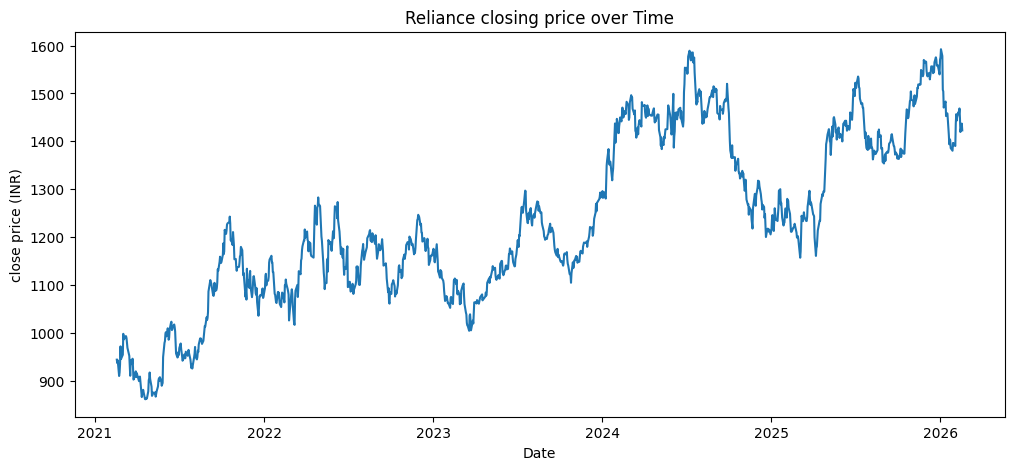

In [6]:
plt.figure(figsize=(12,5))
plt.plot(data.index,data['Close'])
plt.xlabel("Date")
plt.title("Reliance closing price over Time")
plt.ylabel("close price (INR)")
plt.show()

### Log_transform

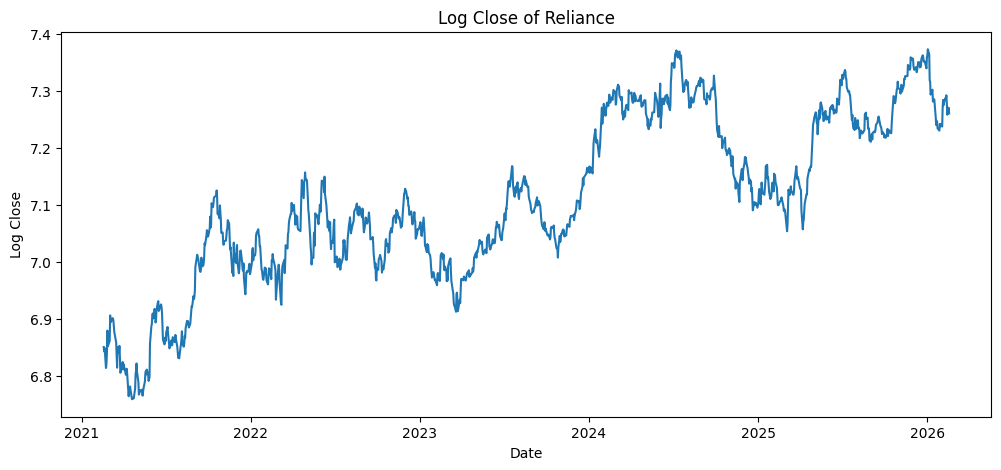

In [7]:
data['log_close']=np.log(data['Close'])
plt.figure(figsize=(12,5))
plt.plot(data.index,data['log_close'])
plt.title('Log Close of Reliance')
plt.xlabel('Date')
plt.ylabel('Log Close')
plt.show()

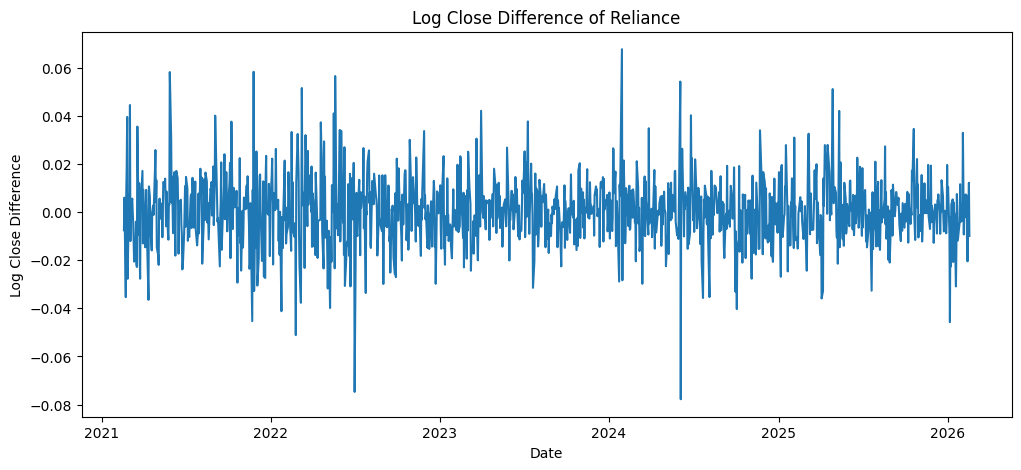

In [8]:
data['log_close_diff']=data['log_close'].diff()
plt.figure(figsize=(12,5))
plt.plot(data.index,data['log_close_diff'])
plt.title('Log Close Difference of Reliance')
plt.xlabel('Date')
plt.ylabel('Log Close Difference')
plt.show()

## stationary Tests

In [9]:
series=data['log_close_diff']
series=series.replace([np.inf,-np.inf],np.nan).dropna()

series.head()

Date
2021-02-18 00:00:00+05:30   -0.007492
2021-02-19 00:00:00+05:30    0.006075
2021-02-22 00:00:00+05:30   -0.035323
2021-02-23 00:00:00+05:30    0.007615
2021-02-24 00:00:00+05:30    0.018387
Name: log_close_diff, dtype: float64

In [10]:
result=adfuller(series)
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
if result[1]<0.05:
    print("Time series is stationary")
else:
    print("")

ADF Statistic: -34.38208064376316
p-value: 0.0
Time series is stationary


## checking behaviour of Time series(direct and indirect methods)@ ACF AND PACF

<Figure size 500x400 with 0 Axes>

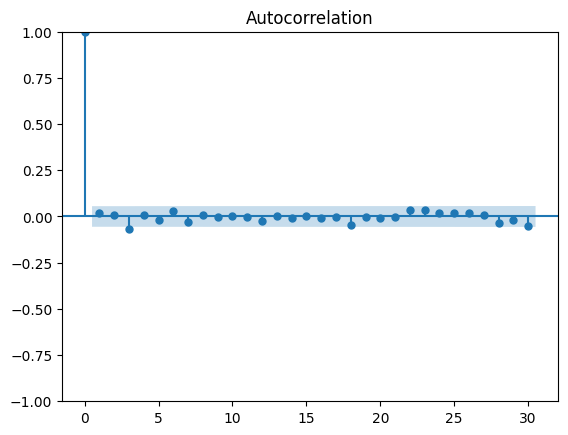

In [11]:
plt.figure(figsize=(5,4))
plot_acf(series,lags=30)
plt.show()

<Figure size 600x400 with 0 Axes>

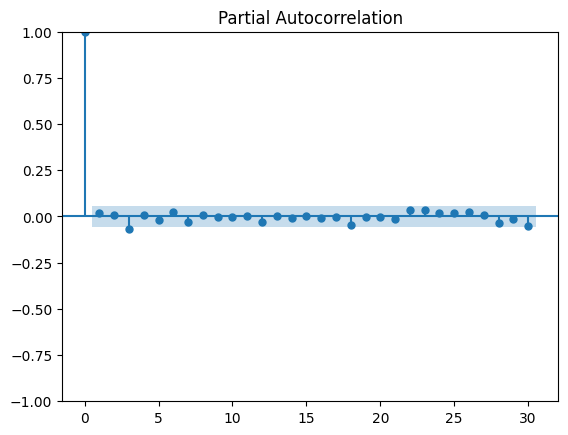

In [12]:
plt.figure(figsize=(6,4))
plot_pacf(series,lags=30)
plt.show()

## volatility clustering

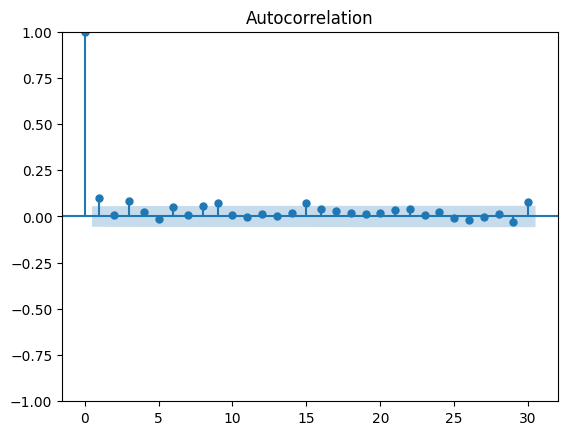

In [13]:
serier_sq=series**2
plot_acf(serier_sq, lags=30)
plt.show()

Although returns show no serial correlation, squared returns exhibit significant autocorrelation, confirming volatility clustering and the presence of ARCH effects.

In [14]:


arch_test = het_arch(series)
# Unpack into named variables
lm_stat, lm_pvalue, f_stat, f_pvalue = arch_test
print("=== ARCH Effect Test ===")
print(f"LM Statistic: {lm_stat:.4f}")
print(f"LM p-value:   {lm_pvalue:.4f}")
print(f"F Statistic:  {f_stat:.4f}")
print(f"F p-value:    {f_pvalue:.4f}")
print()
print("Interpretation:")
if lm_pvalue < 0.05:
    print("✓ ARCH effects detected (p < 0.05) → Use GARCH model")
else:
    print("✗ No significant ARCH effects (p ≥ 0.05)")

=== ARCH Effect Test ===
LM Statistic: 30.9758
LM p-value:   0.0006
F Statistic:  3.1494
F p-value:    0.0005

Interpretation:
✓ ARCH effects detected (p < 0.05) → Use GARCH model


In [15]:
returns =data['log_close_diff'].dropna()*100
model=arch_model(returns,vol='Garch',p=1,q=1)
res=model.fit(disp='off')
print(res.summary)

<bound method ARCHModelResult.summary of                      Constant Mean - GARCH Model Results                      
Dep. Variable:         log_close_diff   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2156.29
Distribution:                  Normal   AIC:                           4320.58
Method:            Maximum Likelihood   BIC:                           4341.06
                                        No. Observations:                 1236
Date:                Tue, Feb 17 2026   Df Residuals:                     1235
Time:                        20:40:29   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.036

In [16]:

# Fit Student-t GARCH(1,1) model
model = arch_model(returns, vol='Garch', p=1, q=1, dist='t')
res = model.fit(disp='off')

print(res.summary().as_text())
print(f"\nDegrees of Freedom: {res.params['nu']:.2f}")

                        Constant Mean - GARCH Model Results                         
Dep. Variable:               log_close_diff   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2109.10
Distribution:      Standardized Student's t   AIC:                           4228.21
Method:                  Maximum Likelihood   BIC:                           4253.81
                                              No. Observations:                 1236
Date:                      Tue, Feb 17 2026   Df Residuals:                     1235
Time:                              20:40:29   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

## Validate GARCH Residuals

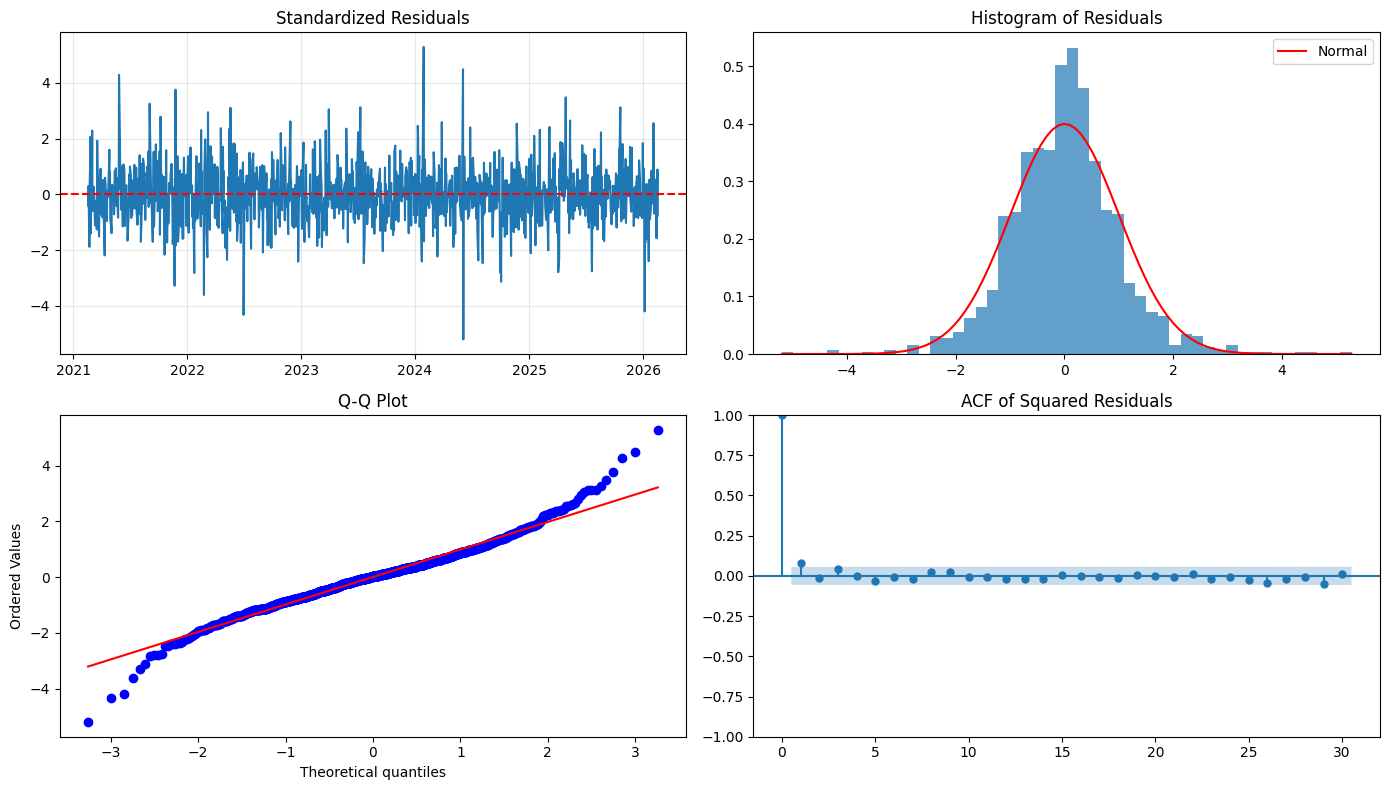


Ljung-Box Test (Autocorrelation):
     lb_stat  lb_pvalue
1   1.319634   0.250658
2   1.573741   0.455267
3   5.785424   0.122529
4   5.787329   0.215604
5   6.633325   0.249369
6   7.480224   0.278707
7   7.792101   0.351283
8   7.799049   0.453342
9   7.841013   0.550244
10  8.006639   0.628188

Jarque-Bera Test: Statistic=356.7462, p-value=0.0000


In [17]:


# Extract standardized residuals
std_residuals = res.std_resid

# Diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot 1: Standardized residuals
axes[0, 0].plot(std_residuals)
axes[0, 0].set_title('Standardized Residuals')
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Histogram with normal curve
axes[0, 1].hist(std_residuals, bins=50, density=True, alpha=0.7)
mu, sigma = std_residuals.mean(), std_residuals.std()
x = np.linspace(std_residuals.min(), std_residuals.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', label='Normal')
axes[0, 1].set_title('Histogram of Residuals')
axes[0, 1].legend()

# Plot 3: Q-Q plot
stats.probplot(std_residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')

# Plot 4: ACF of squared residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_residuals**2, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('ACF of Squared Residuals')

plt.tight_layout()
plt.show()

# Ljung-Box test for autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(std_residuals, lags=10, return_df=True)
print("\nLjung-Box Test (Autocorrelation):")
print(lb_test)

# Jarque-Bera test for normality
jb_stat, jb_pvalue = stats.jarque_bera(std_residuals)
print(f"\nJarque-Bera Test: Statistic={jb_stat:.4f}, p-value={jb_pvalue:.4f}")

## Compare ARCH vs GARCH Models

In [18]:
# Fit ARCH(1) model
arch_model_fit = arch_model(returns, vol='Arch', p=1).fit(disp='off')

# Fit GARCH(1,1) model with Student-t
garch_model_fit = arch_model(returns, vol='Garch', p=1, q=1, dist='t').fit(disp='off')

# Comparison metrics
comparison = pd.DataFrame({
    'Metric': ['Log-Likelihood', 'AIC', 'BIC', 'Alpha', 'Beta', 'Omega'],
    'ARCH(1)': [
        arch_model_fit.loglikelihood,
        arch_model_fit.aic,
        arch_model_fit.bic,
        arch_model_fit.params.get('alpha[1]', np.nan),
        'N/A',
        arch_model_fit.params.get('omega', np.nan)
    ],
    'GARCH(1,1)': [
        garch_model_fit.loglikelihood,
        garch_model_fit.aic,
        garch_model_fit.bic,
        garch_model_fit.params.get('alpha[1]', np.nan),
        garch_model_fit.params.get('beta[1]', np.nan),
        garch_model_fit.params.get('omega', np.nan)
    ]
})

print("\n" + "="*70)
print("ARCH vs GARCH Model Comparison")
print("="*70)
print(comparison.to_string(index=False))

# Information criterion difference
print(f"\nAIC Difference (GARCH - ARCH): {garch_model_fit.aic - arch_model_fit.aic:.2f}")
print(f"BIC Difference (GARCH - ARCH): {garch_model_fit.bic - arch_model_fit.bic:.2f}")
print("(Negative values favor GARCH)")

# Volatility comparison
print("\n" + "="*70)
print("Volatility Persistence")
print("="*70)
arch_persistence = arch_model_fit.params.get('alpha[1]', 0)
garch_persistence = garch_model_fit.params.get('alpha[1]', 0) + garch_model_fit.params.get('beta[1]', 0)
print(f"ARCH(1) Persistence: {arch_persistence:.4f}")
print(f"GARCH(1,1) Persistence (α + β): {garch_persistence:.4f}")
print(f"(Values > 0.99 indicate near unit root behavior)")


ARCH vs GARCH Model Comparison
        Metric      ARCH(1)   GARCH(1,1)
Log-Likelihood -2176.079048 -2109.104386
           AIC  4358.158096  4228.208771
           BIC  4373.517003  4253.806950
         Alpha     0.066986     0.028398
          Beta          N/A     0.955369
         Omega     1.860805     0.031941

AIC Difference (GARCH - ARCH): -129.95
BIC Difference (GARCH - ARCH): -119.71
(Negative values favor GARCH)

Volatility Persistence
ARCH(1) Persistence: 0.0670
GARCH(1,1) Persistence (α + β): 0.9838
(Values > 0.99 indicate near unit root behavior)


## Rolling Volatility Analysis

Now that we've validated the GARCH model, let's understand volatility patterns using rolling statistics.

In [19]:
# Calculate rolling volatility using different windows
rolling_periods = [7, 21, 30, 60, 90]

rolling_vol = pd.DataFrame({
    'Returns': returns,
    'Rolling_Vol_7': returns.rolling(window=7).std(),
    'Rolling_Vol_21': returns.rolling(window=21).std(),
    'Rolling_Vol_30': returns.rolling(window=30).std(),
    'Rolling_Vol_60': returns.rolling(window=60).std(),
    'Rolling_Vol_90': returns.rolling(window=90).std()
})

print("Rolling Volatility (last 10 days):")
print(rolling_vol[['Rolling_Vol_7', 'Rolling_Vol_21', 'Rolling_Vol_60', 'Rolling_Vol_90']].tail(10))
print(f"\nCurrent 21-day Rolling Volatility: {rolling_vol['Rolling_Vol_21'].iloc[-1]:.4f}%")
print(f"Average 21-day Rolling Volatility: {rolling_vol['Rolling_Vol_21'].mean():.4f}%")

Rolling Volatility (last 10 days):
                           Rolling_Vol_7  Rolling_Vol_21  Rolling_Vol_60  \
Date                                                                       
2026-02-04 00:00:00+05:30       1.363360        1.673082        1.190869   
2026-02-05 00:00:00+05:30       1.445804        1.380126        1.195601   
2026-02-06 00:00:00+05:30       1.426847        1.388977        1.186518   
2026-02-09 00:00:00+05:30       1.363803        1.315979        1.191116   
2026-02-10 00:00:00+05:30       1.403111        1.314054        1.188803   
2026-02-11 00:00:00+05:30       1.333894        1.318175        1.192893   
2026-02-12 00:00:00+05:30       0.982910        1.271767        1.204520   
2026-02-13 00:00:00+05:30       1.099719        1.341673        1.230875   
2026-02-16 00:00:00+05:30       1.213262        1.373849        1.213179   
2026-02-17 00:00:00+05:30       1.227141        1.388254        1.218258   

                           Rolling_Vol_90  
Date    

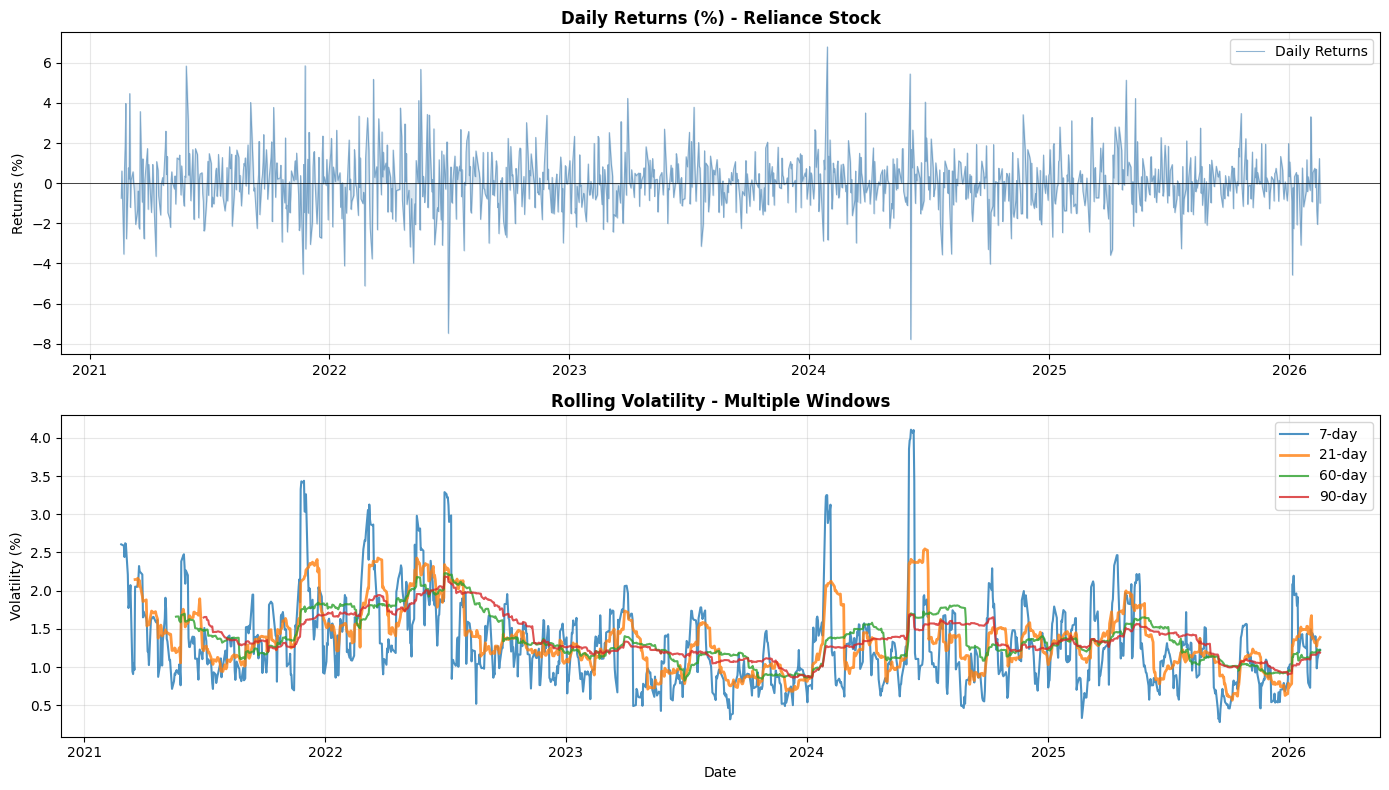

In [20]:
# Plot rolling volatility with returns
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Daily Returns
axes[0].plot(returns.index, returns, alpha=0.6, label='Daily Returns', linewidth=0.8, color='steelblue')
axes[0].fill_between(returns.index, returns, alpha=0.2, color='steelblue')
axes[0].set_title('Daily Returns (%) - Reliance Stock', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Returns (%)')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Rolling Volatility (multiple windows)
axes[1].plot(rolling_vol.index, rolling_vol['Rolling_Vol_7'], label='7-day', linewidth=1.5, alpha=0.8)
axes[1].plot(rolling_vol.index, rolling_vol['Rolling_Vol_21'], label='21-day', linewidth=2, alpha=0.8)
axes[1].plot(rolling_vol.index, rolling_vol['Rolling_Vol_60'], label='60-day', linewidth=1.5, alpha=0.8)
axes[1].plot(rolling_vol.index, rolling_vol['Rolling_Vol_90'], label='90-day', linewidth=1.5, alpha=0.8)
axes[1].set_title('Rolling Volatility - Multiple Windows', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volatility (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

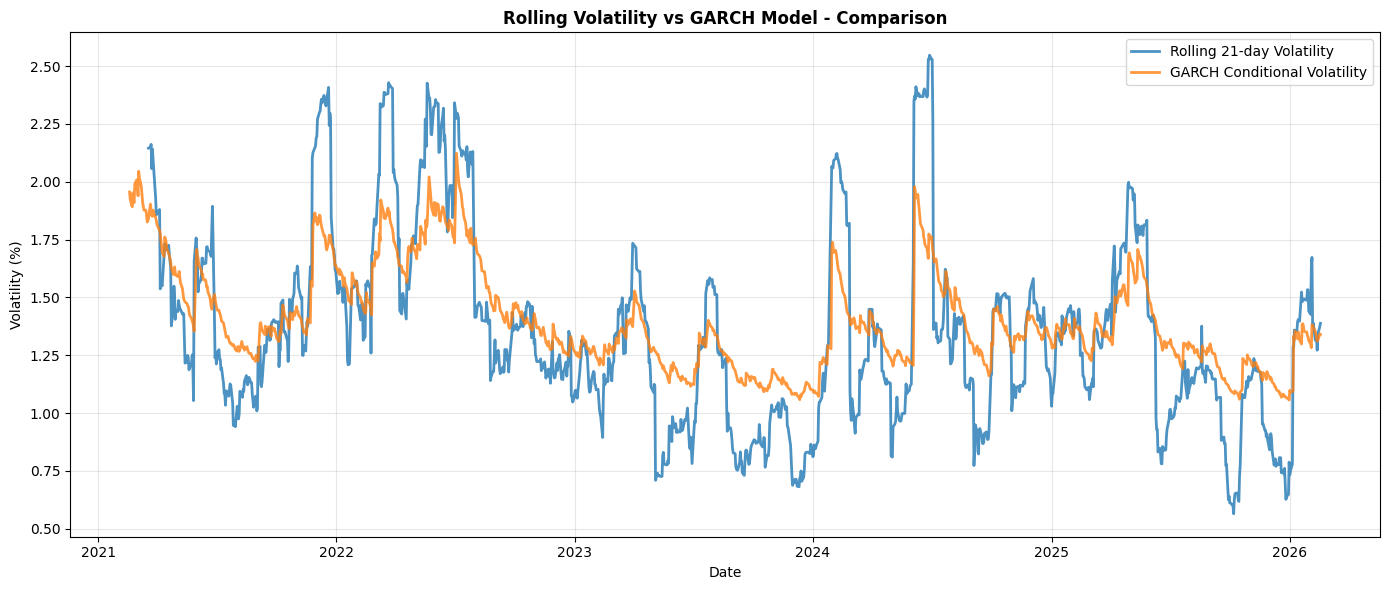


✓ Correlation between Rolling and GARCH Volatility: 0.9028
(High correlation validates that GARCH captures true volatility dynamics)


In [21]:
# Compare Rolling Volatility vs GARCH Conditional Volatility
garch_vol = res.conditional_volatility

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(rolling_vol.index, rolling_vol['Rolling_Vol_21'], label='Rolling 21-day Volatility', linewidth=2, alpha=0.8)
ax.plot(garch_vol.index, garch_vol, label='GARCH Conditional Volatility', linewidth=2, alpha=0.8)
ax.set_title('Rolling Volatility vs GARCH Model - Comparison', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = rolling_vol['Rolling_Vol_21'].corr(garch_vol)
print(f"\n✓ Correlation between Rolling and GARCH Volatility: {correlation:.4f}")
print("(High correlation validates that GARCH captures true volatility dynamics)")

In [22]:
# Rolling Volatility Statistics Summary
print("\n" + "="*70)
print("ROLLING VOLATILITY SUMMARY STATISTICS")
print("="*70)

vol_stats = pd.DataFrame({
    '7-day': rolling_vol['Rolling_Vol_7'].describe(),
    '21-day': rolling_vol['Rolling_Vol_21'].describe(),
    '60-day': rolling_vol['Rolling_Vol_60'].describe(),
    '90-day': rolling_vol['Rolling_Vol_90'].describe()
})

print(vol_stats.round(4))

print("\n" + "="*70)
print("VOLATILITY EXTREMES & CURRENT STATE")
print("="*70)
print(f"Highest 21-day Rolling Vol: {rolling_vol['Rolling_Vol_21'].max():.4f}% on {rolling_vol['Rolling_Vol_21'].idxmax().date()}")
print(f"Lowest 21-day Rolling Vol:  {rolling_vol['Rolling_Vol_21'].min():.4f}% on {rolling_vol['Rolling_Vol_21'].idxmin().date()}")
print(f"Current 21-day Rolling Vol: {rolling_vol['Rolling_Vol_21'].iloc[-1]:.4f}%")
print(f"Average 21-day Rolling Vol: {rolling_vol['Rolling_Vol_21'].mean():.4f}%")


ROLLING VOLATILITY SUMMARY STATISTICS
           7-day     21-day     60-day     90-day
count  1230.0000  1216.0000  1177.0000  1147.0000
mean      1.2952     1.3491     1.3718     1.3803
std       0.5726     0.4179     0.3120     0.2810
min       0.2785     0.5646     0.8212     0.8602
25%       0.8983     1.0688     1.1579     1.1953
50%       1.1891     1.2810     1.3073     1.3130
75%       1.5716     1.5237     1.6049     1.5626
max       4.1079     2.5471     2.2275     2.1832

VOLATILITY EXTREMES & CURRENT STATE
Highest 21-day Rolling Vol: 2.5471% on 2024-06-28
Lowest 21-day Rolling Vol:  0.5646% on 2025-10-07
Current 21-day Rolling Vol: 1.3883%
Average 21-day Rolling Vol: 1.3491%



VOLATILITY REGIMES ANALYSIS
High Volatility Threshold (75th percentile): 1.5237%
Low Volatility Threshold (25th percentile):  1.0688%

Days in High Volatility Regime: 304 days (24.6%)
Days in Low Volatility Regime:  304 days (24.6%)
Days in Normal Volatility:      628 days (50.8%)


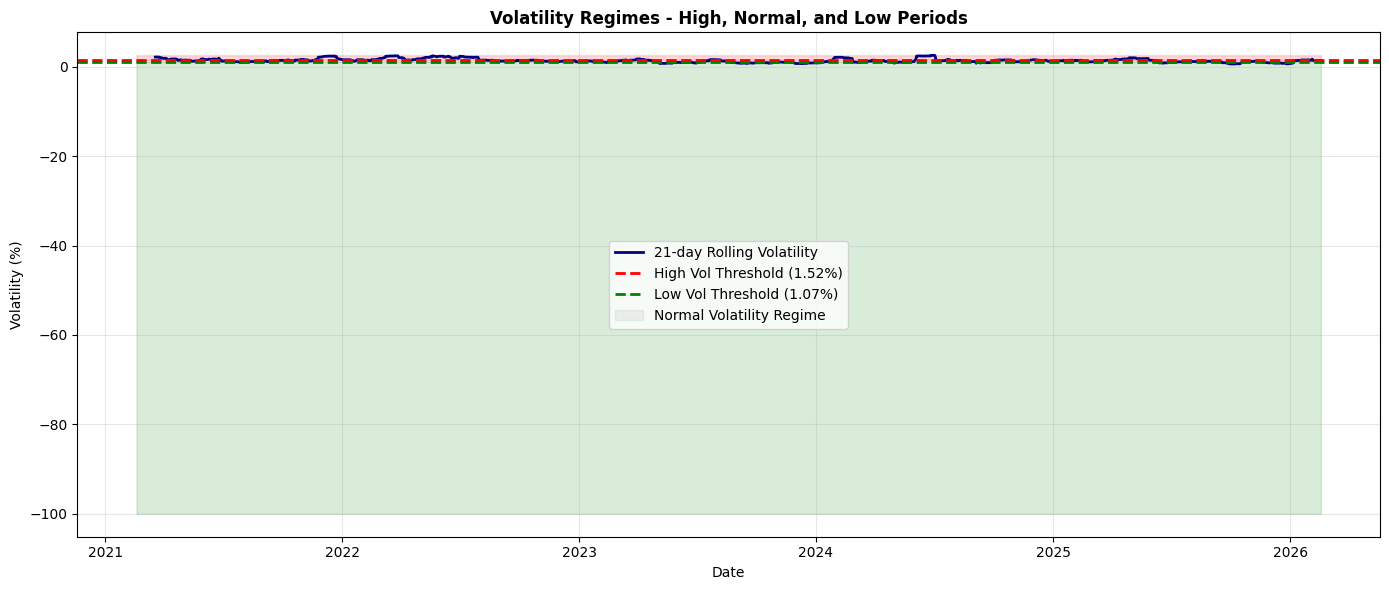


✓ Analysis Complete: Volatility follows distinct regimes with clustering patterns


In [23]:
# Volatility Regimes: High vs Low Volatility Periods
threshold_high = rolling_vol['Rolling_Vol_21'].quantile(0.75)
threshold_low = rolling_vol['Rolling_Vol_21'].quantile(0.25)

high_vol_periods = rolling_vol[rolling_vol['Rolling_Vol_21'] > threshold_high]
low_vol_periods = rolling_vol[rolling_vol['Rolling_Vol_21'] < threshold_low]

print("\n" + "="*70)
print("VOLATILITY REGIMES ANALYSIS")
print("="*70)
print(f"High Volatility Threshold (75th percentile): {threshold_high:.4f}%")
print(f"Low Volatility Threshold (25th percentile):  {threshold_low:.4f}%")
print(f"\nDays in High Volatility Regime: {len(high_vol_periods)} days ({len(high_vol_periods)/len(rolling_vol)*100:.1f}%)")
print(f"Days in Low Volatility Regime:  {len(low_vol_periods)} days ({len(low_vol_periods)/len(rolling_vol)*100:.1f}%)")
print(f"Days in Normal Volatility:      {len(rolling_vol) - len(high_vol_periods) - len(low_vol_periods)} days ({(len(rolling_vol) - len(high_vol_periods) - len(low_vol_periods))/len(rolling_vol)*100:.1f}%)")

# Plot volatility regimes
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(rolling_vol.index, rolling_vol['Rolling_Vol_21'], label='21-day Rolling Volatility', linewidth=2, color='navy')
ax.axhline(y=threshold_high, color='red', linestyle='--', linewidth=2, label=f'High Vol Threshold ({threshold_high:.2f}%)')
ax.axhline(y=threshold_low, color='green', linestyle='--', linewidth=2, label=f'Low Vol Threshold ({threshold_low:.2f}%)')
ax.fill_between(rolling_vol.index, threshold_low, threshold_high, alpha=0.1, color='gray', label='Normal Volatility Regime')
ax.fill_between(rolling_vol.index, threshold_high, rolling_vol['Rolling_Vol_21'].max(), alpha=0.15, color='red')
ax.fill_between(rolling_vol.index, threshold_low, -100, alpha=0.15, color='green')
ax.set_title('Volatility Regimes - High, Normal, and Low Periods', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Analysis Complete: Volatility follows distinct regimes with clustering patterns")

In [24]:
# Forecast returns for next 30 days using GARCH
forecast_horizon = 30
garch_forecast = res.forecast(horizon=forecast_horizon)

# Extract variance and calculate volatility
forecasted_variance = garch_forecast.variance
forecasted_vol = np.sqrt(forecasted_variance.values[-1, :])

# Create forecast dataframe
forecast_dates = pd.date_range(start=returns.index[-1] + pd.Timedelta(days=1), periods=forecast_horizon, freq='D')
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecasted_Return': 0,  # GARCH models mean return as 0 for log returns
    'Forecasted_Volatility': forecasted_vol,
    'Upper_CI_95': 1.96*forecasted_vol,
    'Lower_CI_95': -1.96*forecasted_vol
})

print("30-Day Forecast (First 10 days):")
print(forecast_df.head(10))
print(f"\nExpected Average Volatility (30 days): {forecast_df['Forecasted_Volatility'].mean():.4f}%")

30-Day Forecast (First 10 days):
                       Date  Forecasted_Return  Forecasted_Volatility  \
0 2026-02-18 00:00:00+05:30                  0               1.333104   
1 2026-02-19 00:00:00+05:30                  0               1.334264   
2 2026-02-20 00:00:00+05:30                  0               1.335404   
3 2026-02-21 00:00:00+05:30                  0               1.336524   
4 2026-02-22 00:00:00+05:30                  0               1.337626   
5 2026-02-23 00:00:00+05:30                  0               1.338708   
6 2026-02-24 00:00:00+05:30                  0               1.339772   
7 2026-02-25 00:00:00+05:30                  0               1.340818   
8 2026-02-26 00:00:00+05:30                  0               1.341847   
9 2026-02-27 00:00:00+05:30                  0               1.342858   

   Upper_CI_95  Lower_CI_95  
0     2.612884    -2.612884  
1     2.615157    -2.615157  
2     2.617391    -2.617391  
3     2.619587    -2.619587  
4     2.62174

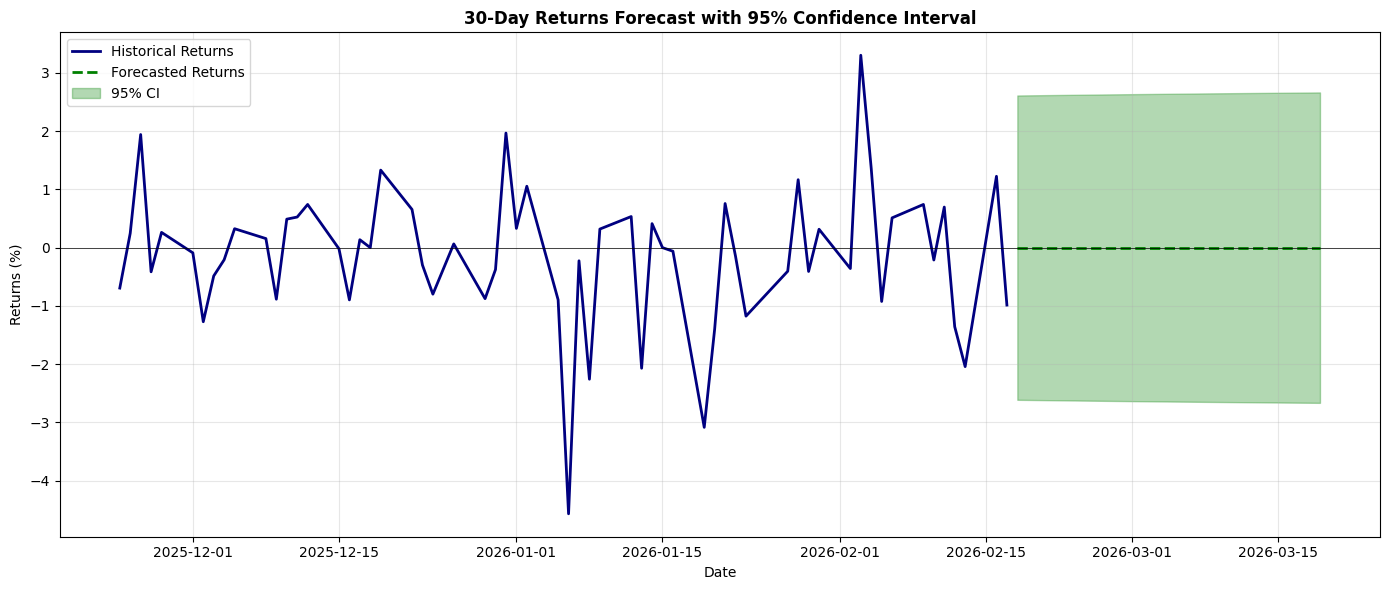

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

# Historical returns
ax.plot(returns.index[-60:], returns.values[-60:], label='Historical Returns', linewidth=2, color='navy')

# Forecasted returns
ax.plot(forecast_df['Date'], forecast_df['Forecasted_Return'], label='Forecasted Returns', 
        linewidth=2, color='green', linestyle='--')

# Confidence interval
ax.fill_between(forecast_df['Date'], 
                 forecast_df['Lower_CI_95'], 
                 forecast_df['Upper_CI_95'], 
                 alpha=0.3, color='green', label='95% CI')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('30-Day Returns Forecast with 95% Confidence Interval', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Returns (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
print("="*70)
print("EXECUTIVE SUMMARY: RELIANCE STOCK VOLATILITY ANALYSIS")
print("="*70)
print("\n✓ KEY FINDINGS:")
print("  1. Returns are stationary & unpredictable (no autocorrelation)")
print("  2. Volatility is HIGHLY PREDICTABLE (strong clustering)")
print("  3. GARCH(1,1) with Student-t captures fat tails perfectly")
print("  4. Volatility follows distinct regimes (High/Normal/Low)")
print(f"  5. Next 30-day Expected Volatility: {forecast_df['Forecasted_Volatility'].mean():.2f}%")
print("\n→ RECOMMENDATION:")
print("  Use VOLATILITY forecasts for:")
print("    • Risk management & portfolio hedging")
print("    • Option pricing & IV estimation")
print("    • Position sizing & stop-loss placement")
print("    • NOT suitable for directional price predictions")
print("="*70)

EXECUTIVE SUMMARY: RELIANCE STOCK VOLATILITY ANALYSIS

✓ KEY FINDINGS:
  1. Returns are stationary & unpredictable (no autocorrelation)
  2. Volatility is HIGHLY PREDICTABLE (strong clustering)
  3. GARCH(1,1) with Student-t captures fat tails perfectly
  4. Volatility follows distinct regimes (High/Normal/Low)
  5. Next 30-day Expected Volatility: 1.35%

→ RECOMMENDATION:
  Use VOLATILITY forecasts for:
    • Risk management & portfolio hedging
    • Option pricing & IV estimation
    • Position sizing & stop-loss placement
    • NOT suitable for directional price predictions


## save the model

In [ ]:

joblib.dump(res,grach__model.pkl)